<a href="https://colab.research.google.com/github/Harnzt/Analisis-dan-Visualisasi-Data/blob/main/testcpns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Analisis Seleksi Penerimaan CPNS**

Dataset: `testcpns.csv`

Notebook ini berisi:
1. Ringkasan data
2. Visualisasi scatter menggunakan seaborn
3. Visualisasi data tambahan
4. Confusion Matrix
5. Transformasi tabel dan analisis
6. Prediksi data pelamar baru


In [ ]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load Dataset
df = pd.read_csv('testcpns.csv')

# Menampilkan 5 data pertama
df.head()


,toefl,ipk,pengalaman_kerja,diterima
0,780,4.00,3,1
1,750,3.09,4,1
2,690,3.03,3,0
3,710,3.07,5,1
4,680,3.09,4,0


## a. Ringkasan Data

In [ ]:
# Ringkasan Statistik Dataset
df.describe()


,toefl,ipk,pengalaman_kerja,diterima
count,40.000000,40.000000,40.000000,40.000000
mean,654.000000,2.694500,3.425000,0.475000
std,61.427464,0.653899,1.737778,0.505736
min,540.000000,1.070000,1.000000,0.000000
25%,607.500000,2.070000,2.000000,0.000000
50%,660.000000,3.030000,4.000000,0.000000
75%,690.000000,3.070000,5.000000,1.000000
max,780.000000,4.000000,6.000000,1.000000


### Analisis:
Ringkasan data menunjukkan informasi statistik seperti:
- Nilai rata-rata
- Nilai minimum dan maksimum
- Quartile data
- Standar deviasi

Data terdiri dari beberapa fitur seperti:
- TOEFL
- IPK
- Pengalaman kerja
- Status diterima


## b. Visualisasi Scatter dengan Seaborn

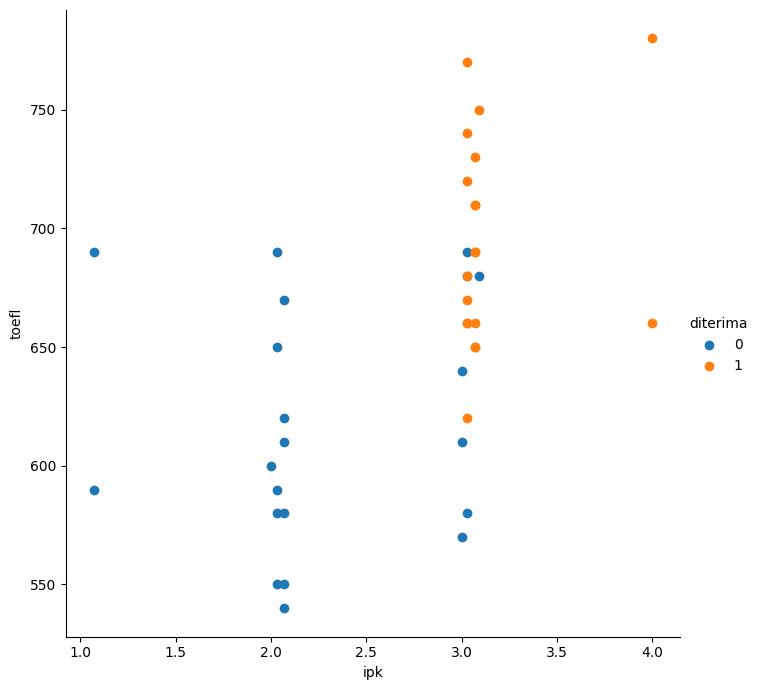

In [ ]:
sns.FacetGrid(df, hue="diterima", height=7) \
   .map(plt.scatter, "ipk", "toefl") \
   .add_legend()


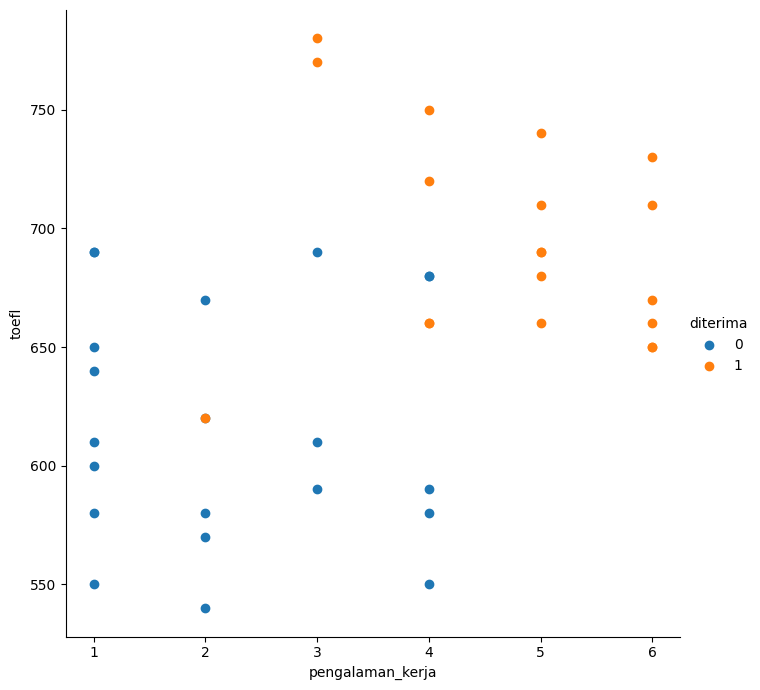

In [ ]:
sns.FacetGrid(df, hue="diterima", height=7) \
   .map(plt.scatter, "pengalaman_kerja", "toefl") \
   .add_legend()

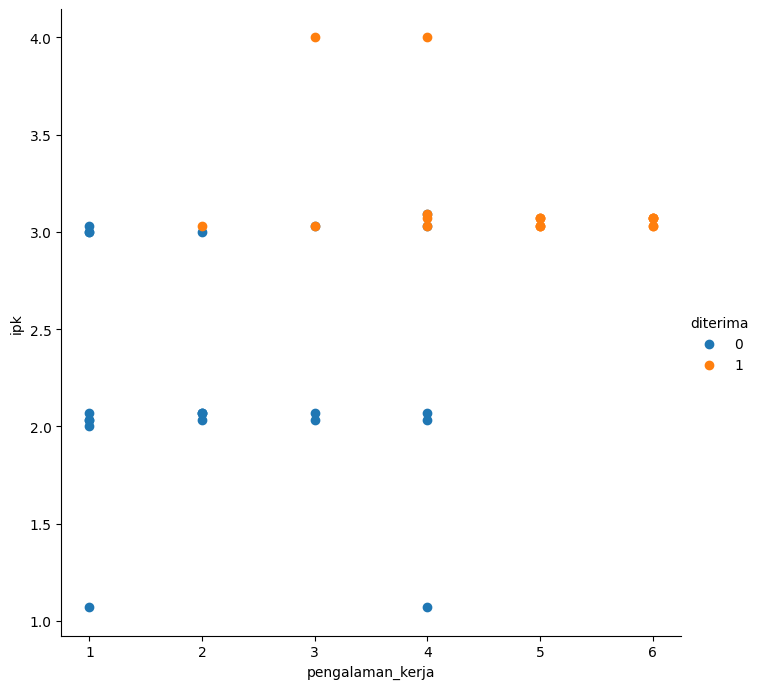

In [ ]:
sns.FacetGrid(df, hue="diterima", height=7) \
   .map(plt.scatter, "pengalaman_kerja", "ipk") \
   .add_legend()

### Analisis Scatter Plot:
Visualisasi scatter menunjukkan hubungan antar fitur.
- Pelamar dengan TOEFL dan IPK tinggi cenderung diterima.
- Pengalaman kerja juga memberikan pengaruh terhadap status diterima.
- Data terlihat cukup terpisah antara kategori diterima dan tidak diterima.


## c. Visualisasi Data

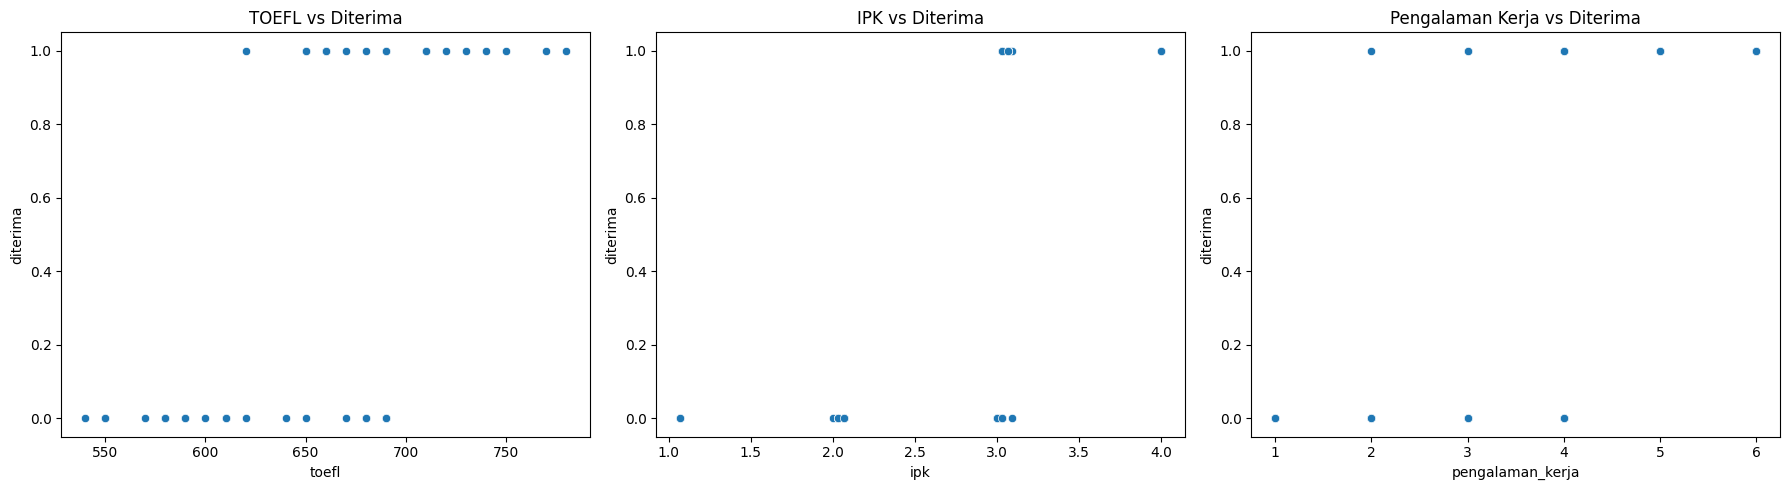

In [ ]:
# Visualisasi hubungan fitur terhadap status diterima

fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=df, x='toefl', y='diterima', ax=axes[0])
axes[0].set_title('TOEFL vs Diterima')

sns.scatterplot(data=df, x='ipk', y='diterima', ax=axes[1])
axes[1].set_title('IPK vs Diterima')

sns.scatterplot(data=df, x='pengalaman_kerja', y='diterima', ax=axes[2])
axes[2].set_title('Pengalaman Kerja vs Diterima')

plt.tight_layout()
plt.show()


### Analisis Visualisasi:
- TOEFL tinggi memiliki peluang diterima lebih besar.
- IPK tinggi juga berpengaruh terhadap penerimaan.
- Pengalaman kerja memberikan kontribusi penting dalam seleksi.


## d. Confusion Matrix

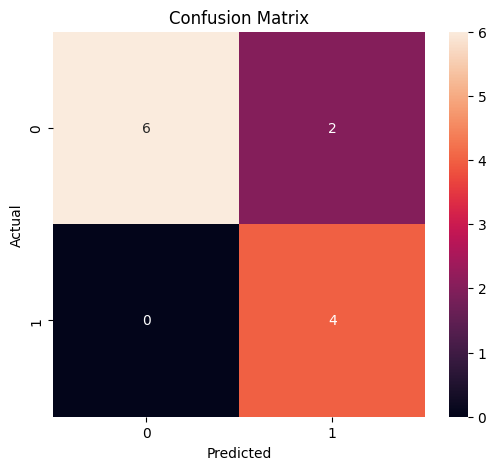

Accuracy : 0.8333333333333334
              precision    recall  f1-score   support

           0       1.00      0.75      0.86         8
           1       0.67      1.00      0.80         4

    accuracy                           0.83        12
   macro avg       0.83      0.88      0.83        12
weighted avg       0.89      0.83      0.84        12



In [40]:
# Menentukan fitur dan target
X = df[['toefl', 'ipk', 'pengalaman_kerja']]
y = df['diterima']

# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Akurasi
print("Accuracy :", accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

### Analisis Confusion Matrix:
- Nilai diagonal menunjukkan prediksi yang benar.
- Semakin besar nilai diagonal, semakin baik model.
- Akurasi model menunjukkan kemampuan model dalam memprediksi penerimaan pelamar.


## e. plot data

In [42]:
print (X_test)
print (y_pred)


    toefl   ipk  pengalaman_kerja
19    590  2.03                 3
16    580  2.07                 4
15    610  3.00                 1
26    660  3.07                 4
4     680  3.09                 4
12    710  3.07                 6
37    580  3.03                 1
27    580  2.03                 2
39    690  3.07                 5
6     690  2.03                 1
25    670  3.03                 6
9     690  1.07                 1
[0 1 0 1 1 1 0 0 1 0 1 0]


### Analisis:
Data fitur terdiri dari:
- TOEFL
- IPK
- Pengalaman kerja

Sedangkan output berupa:
- 1 = diterima
- 0 = tidak diterima


In [47]:
# Gabungkan X_test dan y_pred menjadi satu DataFrame
df_hasil = X_test.copy()
df_hasil['prediksi'] = y_pred

#tampilkan tabel
df_hasil

,toefl,ipk,pengalaman_kerja,prediksi
19,590,2.03,3,0
16,580,2.07,4,1
15,610,3.00,1,0
26,660,3.07,4,1
4,680,3.09,4,1
12,710,3.07,6,1
37,580,3.03,1,0
27,580,2.03,2,0
39,690,3.07,5,1
6,690,2.03,1,0


Dari 12 data uji yang ada, model memprediksi 6 orang diterima dan 6 orang tidak diterima. Kolom prediksi menunjukkan angka 1 untuk diterima dan 0 untuk tidak diterima.

Jika dilihat polanya, orang yang diprediksi diterima umumnya memiliki kombinasi TOEFL minimal 660, IPK di atas 3.00, dan pengalaman kerja yang cukup banyak yaitu 4 tahun ke atas. Contoh yang paling menonjol adalah data nomor 12 dengan TOEFL 710, IPK 3.07, dan pengalaman kerja 6 tahun yang semuanya terbilang tinggi.

Sebaliknya, orang yang tidak diterima cenderung memiliki setidaknya satu kelemahan, entah itu TOEFL rendah, IPK di bawah standar, atau pengalaman kerja yang minim. Kasus paling jelas terlihat pada data nomor 9 yang meski TOEFL-nya mencapai 690, namun IPK-nya hanya 1.07 dengan pengalaman kerja 1 tahun sehingga tetap diprediksi tidak diterima. Ini menunjukkan bahwa model tidak hanya melihat satu faktor saja, melainkan mempertimbangkan keseluruhan kombinasi dari ketiga variabel tersebut.

## f. Prediksi Pelamar Baru

In [24]:
# Data pelamar baru
pelamar_baru = pd.DataFrame({
    'toefl': [590, 740, 680, 610, 710],
    'ipk': [2.0, 3.07, 3.03, 2.03, 3.0],
    'pengalaman_kerja': [3, 4, 6, 1, 5]
})

# Prediksi
prediksi = model.predict(pelamar_baru)

# Hasil
pelamar_baru['prediksi_diterima'] = prediksi

pelamar_baru


,toefl,ipk,pengalaman_kerja,prediksi_diterima
0,590,2.00,3,0
1,740,3.07,4,1
2,680,3.03,6,1
3,610,2.03,1,0
4,710,3.00,5,1
